<a href="https://colab.research.google.com/github/Sneha8126/ML-Projects/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'BPIT Cover Page V1.gdoc', 'BPIT Cover Page V2.gdoc', 'PanCard.pdf', 'MyPassportPhoto.jpeg', 'Sneha_Resume.pdf', 'sample_data', 'Copy of appstoreBadge.svg', 'OOPs Concepts: The Four Pillars.gdoc', 'Forest Fires Regression Implementation Steps.gdoc', 'Taxi Price Prediction Implementation Guide.gdoc', 'spg.csv', 'SCMS_Delivery_History_Dataset.csv', 'taxi_trip_pricing.csv', 'Global YouTube Statistics.csv', 'Heart_Disease_Prediction.csv', 'Transformed Data Set - Sheet1.csv', 'healthcare-dataset-stroke-data.csv', 'House Price Prediction Dataset.csv', 'data.csv', 'Mall_Customers.csv', 'insurance.csv', 'heart.csv', 'train.csv', 'ford.csv', '.ipynb_checkpoints', 'Titanic.csv', 'Amazon.csv', 'Copy of Churn_Modelling.csv', 'twitter_training.csv', 'mobile_recommendation_system_dataset.csv', 'archive (22).zip', 'fruit_dataset', 'Fruit_Freshness_Dataset.zip']


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Fruit_Freshness_Dataset.zip"
extract_path = "/content/fruit_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
import os

print(os.listdir("/content/fruit_dataset"))

['README.dataset.txt', 'Fruit Freshness Dataset']


In [5]:
for root, dirs, files in os.walk("/content/fruit_dataset"):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*60)

/content/fruit_dataset
Folders: ['Fruit Freshness Dataset']
Files: 1
------------------------------------------------------------
/content/fruit_dataset/Fruit Freshness Dataset
Folders: ['Fruit Freshness Dataset']
Files: 0
------------------------------------------------------------
/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset
Folders: ['Strawberry', 'Apple', 'Banana']
Files: 0
------------------------------------------------------------
/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset/Strawberry
Folders: ['Fresh', 'Rotten']
Files: 0
------------------------------------------------------------
/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset/Strawberry/Fresh
Folders: []
Files: 220
------------------------------------------------------------
/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset/Strawberry/Rotten
Folders: []
Files: 44
------------------------------------------------------------
/conten

In [6]:
dataset_path="/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset"

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [8]:
dataset_path="/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset"

IMG_SIZE=(224,224)
BATCH_SIZE=32

train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 529 files belonging to 3 classes.
Using 424 files for training.
Found 529 files belonging to 3 classes.
Using 105 files for validation.


In [8]:
class_names=train_dataset.class_names

print("Classes:",class_names)
print("Total Classes:",len(class_names))

Classes: ['Apple', 'Banana', 'Strawberry']
Total Classes: 3


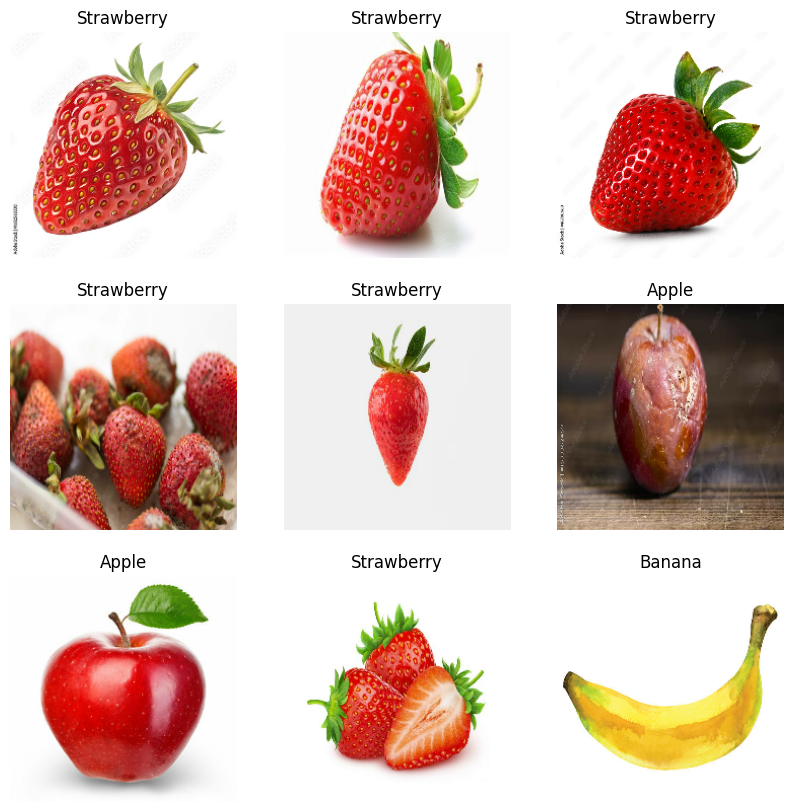

In [9]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [10]:
normalization_layer=tf.keras.layers.Rescaling(1./255)

train_dataset=train_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

validation_dataset=validation_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

In [11]:
AUTOTUNE=tf.data.AUTOTUNE

train_dataset=train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)

validation_dataset=validation_dataset.cache().prefetch(AUTOTUNE)

In [12]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 512ms/step - accuracy: 0.4505 - loss: 2.1896 - val_accuracy: 0.6667 - val_loss: 0.7834
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7146 - loss: 0.6351 - val_accuracy: 0.8286 - val_loss: 0.4488
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8302 - loss: 0.4715 - val_accuracy: 0.8667 - val_loss: 0.3468
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8679 - loss: 0.3539 - val_accuracy: 0.9238 - val_loss: 0.2569
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9033 - loss: 0.2623 - val_accuracy: 0.9238 - val_loss: 0.2453
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9198 - loss: 0.2392 - val_accuracy: 0.9429 - val_loss: 0.2126
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9387 - loss: 0.1755 - val_accuracy: 0.9333 - val_loss: 0.1289
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9623 - loss: 0.1097 - val_accuracy: 0.9143 -

In [16]:
print(class_names)

['Apple', 'Banana', 'Strawberry']


In [17]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9524 - loss: 0.1563
Validation Loss: 0.15630047023296356
Validation Accuracy: 0.9523809552192688


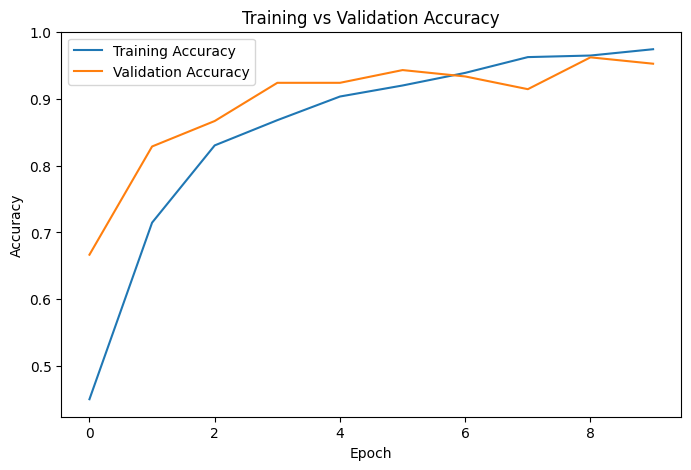

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

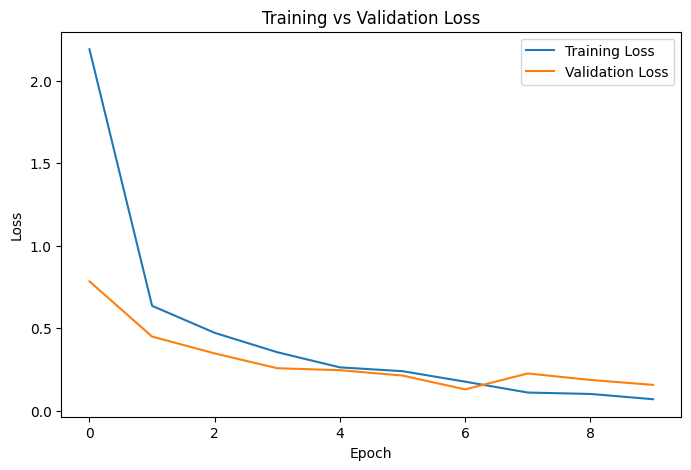

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predictions = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[27  2  0]
 [ 1 21  1]
 [ 0  1 52]]


In [21]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple/Fresh/apple_fresh_001.jpg (1).jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Fruit:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step
Predicted Fruit: Apple


In [22]:
img_path = "/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset/Banana/Fresh/banana_fresh_010 (1).jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Fruit:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Fruit: Banana


In [10]:
import shutil

# Fruit Freshness Classification

In [11]:
source_path="/content/fruit_dataset/Fruit Freshness Dataset/Fruit Freshness Dataset"
target_path="/content/Fresh_vs_Rotten"

os.makedirs(os.path.join(target_path,"Fresh"),exist_ok=True)
os.makedirs(os.path.join(target_path,"Rotten"),exist_ok=True)

for fruit in os.listdir(source_path):

    fruit_folder=os.path.join(source_path,fruit)

    if os.path.isdir(fruit_folder):

        fresh_folder=os.path.join(fruit_folder,"Fresh")
        rotten_folder=os.path.join(fruit_folder,"Rotten")

        if os.path.exists(fresh_folder):
            for img in os.listdir(fresh_folder):
                shutil.copy(
                    os.path.join(fresh_folder,img),
                    os.path.join(target_path,"Fresh",fruit+"_"+img)
                )

        if os.path.exists(rotten_folder):
            for img in os.listdir(rotten_folder):
                shutil.copy(
                    os.path.join(rotten_folder,img),
                    os.path.join(target_path,"Rotten",fruit+"_"+img)
                )

print("Dataset Created Successfully")

Dataset Created Successfully


In [12]:
print(os.listdir("/content/Fresh_vs_Rotten"))

print("Fresh Images:",len(os.listdir("/content/Fresh_vs_Rotten/Fresh")))
print("Rotten Images:",len(os.listdir("/content/Fresh_vs_Rotten/Rotten")))

['Fresh', 'Rotten']
Fresh Images: 377
Rotten Images: 189


In [13]:
dataset_path="/content/Fresh_vs_Rotten"

IMG_SIZE=(224,224)
BATCH_SIZE=32

train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 529 files belonging to 2 classes.
Using 424 files for training.
Found 529 files belonging to 2 classes.
Using 105 files for validation.


In [14]:
class_names=train_dataset.class_names

print(class_names)

['Fresh', 'Rotten']


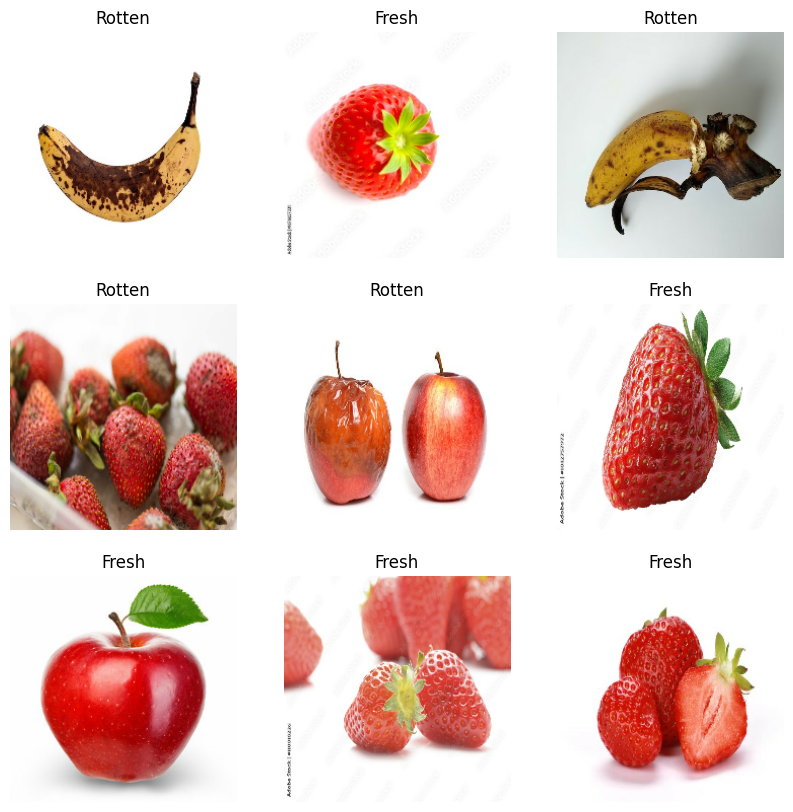

In [15]:
plt.figure(figsize=(10,10))

for images,labels in train_dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [16]:
normalization_layer=tf.keras.layers.Rescaling(1./255)

train_dataset=train_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)

validation_dataset=validation_dataset.map(
    lambda x,y:(normalization_layer(x),y)
)